<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [4]:
# Clone the group C repo
!git clone https://github.com/zzsc9020-teamc/project.git

# Make a data folder
!mkdir -p data

# Join the forecast demand parts into a single zip
!cat project/data/NSW/forecastdemand_nsw.csv.zip.part* > data/forecastdemand_nsw.csv.zip

# Unzip the three data files into the data folder
!unzip data/forecastdemand_nsw.csv.zip -d data
!unzip project/data/NSW/temperature_nsw.csv.zip -d data
!unzip project/data/NSW/totaldemand_nsw.csv.zip -d data

# Clean up the joined zip
!rm data/forecastdemand_nsw.csv.zip

# Quick check: list the data files
!ls -lh data

fatal: destination path 'project' already exists and is not an empty directory.
Archive:  data/forecastdemand_nsw.csv.zip
  inflating: data/forecastdemand_nsw.csv  
Archive:  project/data/NSW/temperature_nsw.csv.zip
  inflating: data/temperature_nsw.csv  
Archive:  project/data/NSW/totaldemand_nsw.csv.zip
  inflating: data/totaldemand_nsw.csv  
total 718M
-rw-rw-r-- 1 root root 706M Apr 21  2021 forecastdemand_nsw.csv
-rw-rw-r-- 1 root root 6.6M Apr 21  2021 temperature_nsw.csv
-rw-rw-r-- 1 root root 5.6M Apr 21  2021 totaldemand_nsw.csv


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

PATH_FORECAST = "data/forecastdemand_nsw.csv"
PATH_TEMP     = "data/temperature_nsw.csv"
PATH_ACTUAL   = "data/totaldemand_nsw.csv"

def dt_dayfirst(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)

def dt_us(s):
    s = s.astype(str).str.strip().str.replace(r"(\d{1,2})/(\d{1,2})/(\d{2})(?!\d)", r"\1/\2/20\3", regex=True)
    return pd.to_datetime(s, errors="coerce", dayfirst=False, infer_datetime_format=True)

# daily actual peak
a = (pd.read_csv(PATH_ACTUAL, usecols=["DATETIME","TOTALDEMAND","REGIONID"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
a["DATETIME"] = dt_dayfirst(a["DATETIME"])
a["ACTUAL"] = pd.to_numeric(a["TOTALDEMAND"], errors="coerce")
a = a.dropna(subset=["DATETIME","ACTUAL"])
a["DATE"] = a["DATETIME"].dt.floor("D")
daily_actual = a.groupby("DATE", as_index=False)["ACTUAL"].max().rename(columns={"ACTUAL":"ACTUAL_PEAK"})

# daily max temp
t = pd.read_csv(PATH_TEMP).rename(columns={"TemperatureTEMPERATURE":"TEMPERATURE"})
t["DATETIME"] = dt_dayfirst(t["DATETIME"])
t["TEMPERATURE"] = pd.to_numeric(t["TEMPERATURE"], errors="coerce")
t = t.dropna(subset=["DATETIME","TEMPERATURE"])
t["DATE"] = t["DATETIME"].dt.floor("D")
daily_temp = t.groupby("DATE", as_index=False)["TEMPERATURE"].max().rename(columns={"TEMPERATURE":"TEMP_MAX"})

# Forecast max from day before
f = (pd.read_csv(PATH_FORECAST, usecols=["DATETIME","FORECASTDEMAND","REGIONID","LASTCHANGED"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
f["DATETIME"]    = dt_us(f["DATETIME"])
f["LASTCHANGED"] = dt_us(f["LASTCHANGED"])
f["FORECASTDEMAND"] = pd.to_numeric(f["FORECASTDEMAND"], errors="coerce")
f = f.dropna(subset=["DATETIME","LASTCHANGED","FORECASTDEMAND"])
f["DATE_TARGET"] = f["DATETIME"].dt.floor("D")
f["DATE_ISSUE"]  = f["LASTCHANGED"].dt.floor("D")
f_day_ahead = f.loc[f["DATE_ISSUE"].eq(f["DATE_TARGET"] - pd.Timedelta(days=1))]
daily_forecast = (f_day_ahead.groupby("DATE_TARGET", as_index=False)["FORECASTDEMAND"]
                  .max().rename(columns={"DATE_TARGET":"DATE","FORECASTDEMAND":"FORECAST_PEAK_24H"}))

# Merge
daily = (daily_actual.merge(daily_temp, on="DATE", how="left")
                     .merge(daily_forecast, on="DATE", how="left"))
daily["ERROR"] = daily["ACTUAL_PEAK"] - daily["FORECAST_PEAK_24H"]
daily["YEAR"]  = daily["DATE"].dt.year

/tmp/ipython-input-1832668958.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)
/tmp/ipython-input-1832668958.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(s, errors="coerce", dayfirst=True, infer_datetime_format=True)
/tmp/ipython-input-1832668958.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-co

In [6]:
# Plot
def _quad_fit(x, y, n=200):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.array([]), np.array([])
    xm, xs = x[m].mean(), (x[m].std() or 1.0)
    coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
    xg = np.linspace(x[m].min(), x[m].max(), n)
    return xg, np.polyval(coef, (xg-xm)/xs)

def plot_error_views(d, year=None, bins=7):
    d = d.loc[d["YEAR"].eq(year)] if year is not None else d
    d = d.dropna(subset=["TEMP_MAX","ERROR"]).copy()
    if d.empty: return
    x, e = d["TEMP_MAX"].to_numpy(), d["ERROR"].to_numpy()
    xg, e_fit = _quad_fit(x, e)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1)
    axs[0].scatter(x, e, alpha=0.6, s=12, label="Error (Actual - Forecast 24h)")
    if xg.size: axs[0].plot(xg, e_fit, linewidth=2, label="Quadratic fit")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Error (MW)")
    axs[0].set_title("Error vs max temp"); axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(d["TEMP_MAX"].min(), d["TEMP_MAX"].max(), bins+1)
    d = d.assign(TEMP_BIN=pd.cut(d["TEMP_MAX"], bins=edges, include_lowest=True))
    g = d.groupby("TEMP_BIN", observed=True).agg(mean_error=("ERROR","median"),
                                                 count=("ERROR","size")).reset_index()

    axs[1].bar(np.arange(len(g)), g["mean_error"])
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(np.arange(len(g))); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median error (MW)")
    axs[1].set_title(f"Median error by temperature bin (bins={bins})")
    for i, (val, cnt) in enumerate(zip(g["mean_error"], g["count"])):
        axs[1].text(i, val, f" n={cnt}", ha="center", va="bottom" if val>=0 else "top", fontsize=8)
    axs[1].grid(True, axis="y", alpha=0.3)
    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''}")
    plt.tight_layout(); plt.show()

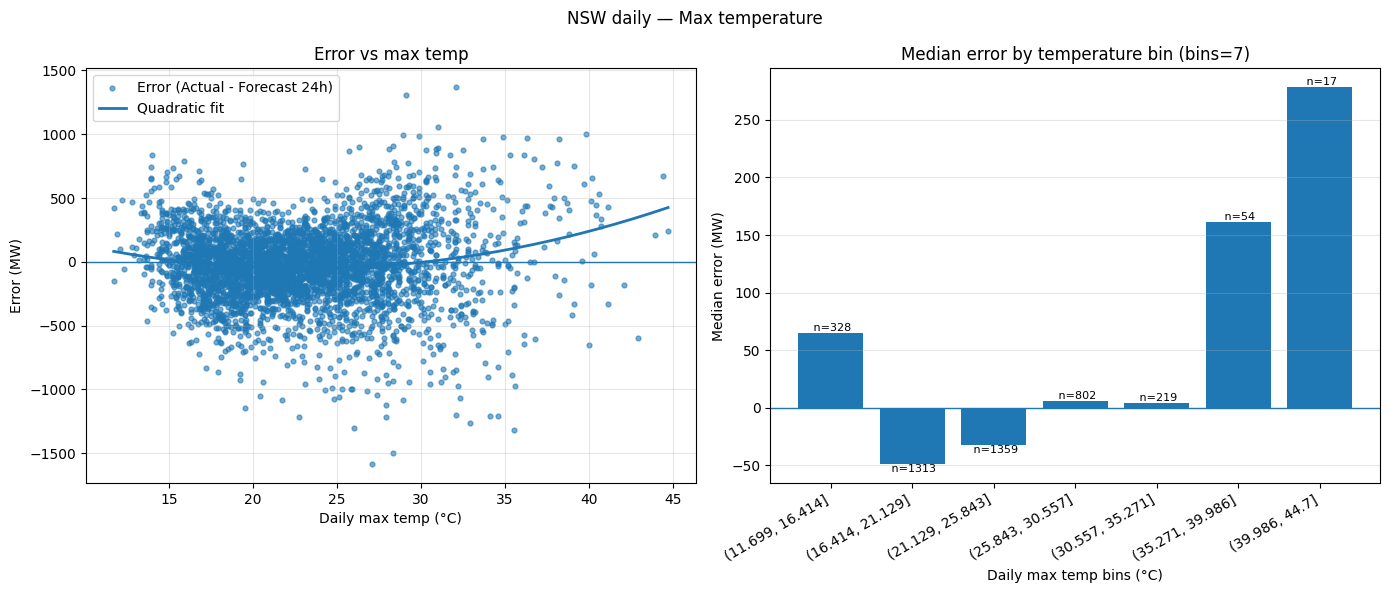

In [7]:
plot_error_views(daily)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}
Forecast (24h) on test: {'MAE': 202.20691931540335, 'RMSE': 279.9894423887162, 'MAPE_pct': np.float64(2.130460142646821)}
RandomForest on test: {'MAE': 193.81657698655172, 'RMSE': 266.90579949657075, 'MAPE_pct': np.float64(2.0406466631337947)}


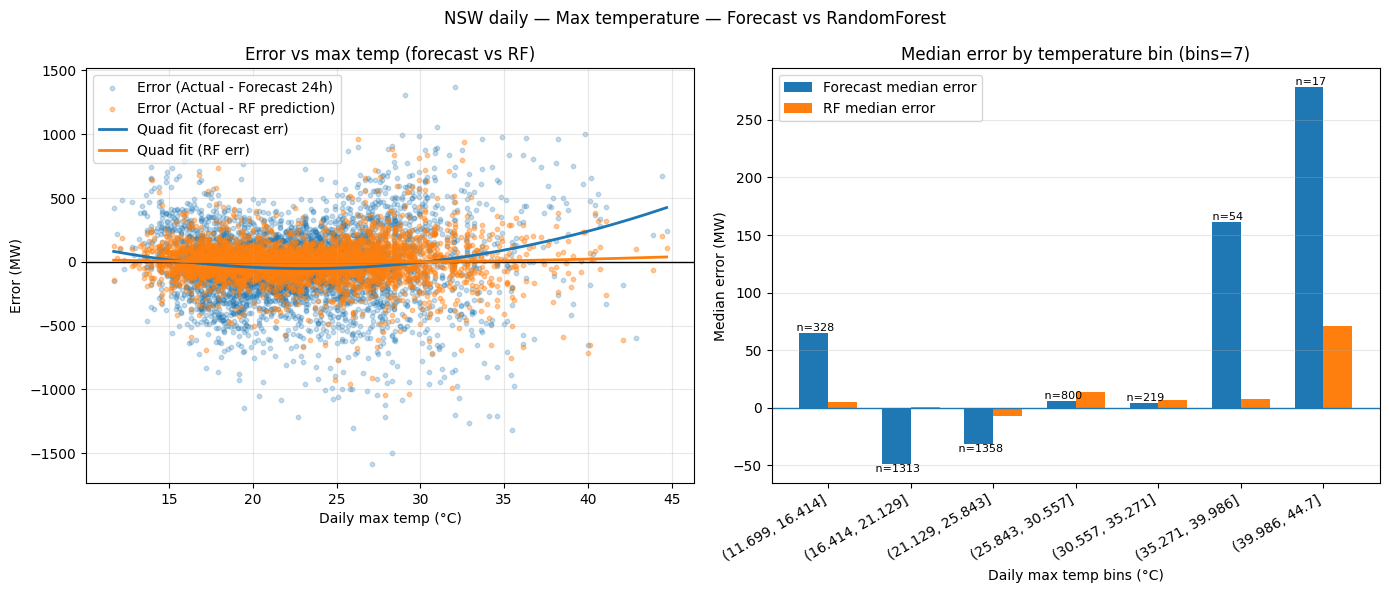

Feature importances (top 10):
FORECAST_PEAK_24H    0.635750
FORECAST_lag1        0.171703
FORECAST_roll3       0.056716
TEMP_MAX             0.034304
TEMP_EXTREME         0.029137
CDD_24               0.022002
DOY_cos              0.010569
DOY_sin              0.008329
TEMP_MAX_lag1        0.006571
TEMP_MAX_roll3       0.006544
dtype: float64
Cold tail: {'n': 421, 'forecast_MAE': 208.52448931116388, 'rf_MAE': 94.65482672208907, 'MAE_red': 113.8696625890748}
Mid range: {'n': 3259, 'forecast_MAE': 199.58114145443386, 'rf_MAE': 87.63513198066825, 'MAE_red': 111.94600947376561}
Hot tail: {'n': 409, 'forecast_MAE': 358.92110024449875, 'rf_MAE': 179.7488186430327, 'MAE_red': 179.17228160146604}


In [8]:
# Random forest model to predict daily peak demand from TEMP_MAX + other features
# Assumes `daily` DataFrame already exists (columns: DATE, ACTUAL_PEAK, TEMP_MAX, FORECAST_PEAK_24H, YEAR, ERROR)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings("ignore")
RSEED = 42

#Prepare features (operate on a copy)
d = daily.copy().sort_values("DATE").reset_index(drop=True)
# Drop rows with missing target or TEMP_MAX
d = d.dropna(subset=["ACTUAL_PEAK","TEMP_MAX"]).reset_index(drop=True)

# Feature engineering
d["FORECAST_PEAK_24H"] = d["FORECAST_PEAK_24H"].fillna(method="ffill").fillna(d["ACTUAL_PEAK"].median())
# Calendar features
d["DOY"] = d["DATE"].dt.dayofyear
# cyclical encoding for day-of-year
d["DOY_sin"] = np.sin(2*np.pi * d["DOY"]/365.25)
d["DOY_cos"] = np.cos(2*np.pi * d["DOY"]/365.25)
d["YEAR"] = d["DATE"].dt.year

# Lags & rolling stats on TEMP_MAX and forecasts (helpful for persistence patterns)
for lag in [1,2,3]:
    d[f"TEMP_MAX_lag{lag}"] = d["TEMP_MAX"].shift(lag)
    d[f"FORECAST_lag{lag}"] = d["FORECAST_PEAK_24H"].shift(lag)

# Rolling mean of previous 3 days
d["TEMP_MAX_roll3"] = d["TEMP_MAX"].shift(1).rolling(3, min_periods=1).mean()
d["FORECAST_roll3"]  = d["FORECAST_PEAK_24H"].shift(1).rolling(3, min_periods=1).mean()

# Degree days (simple): baseline 18°C for heating, 24°C for cooling — you can adjust
d["CDD_24"] = np.clip(d["TEMP_MAX"] - 24.0, 0, None)   # cooling degree days
d["HDD_18"] = np.clip(18.0 - d["TEMP_MAX"], 0, None)  # heating degree days

# Extreme flag: tails of the temp distribution
q10, q90 = np.nanpercentile(d["TEMP_MAX"], [10,90])
d["TEMP_EXTREME"] = ((d["TEMP_MAX"] <= q10) | (d["TEMP_MAX"] >= q90)).astype(int)

# Target
d = d.dropna().reset_index(drop=True)  # drop rows with any NA from lags
y = d["ACTUAL_PEAK"].values

# Candidate predictors
features = [
    "TEMP_MAX","TEMP_MAX_roll3","TEMP_MAX_lag1","TEMP_MAX_lag2","TEMP_MAX_lag3",
    "FORECAST_PEAK_24H","FORECAST_roll3","FORECAST_lag1",
    "DOY_sin","DOY_cos","YEAR",
    "CDD_24","HDD_18","TEMP_EXTREME"
]
X = d[features].astype(float)

#Train/test split: time-wise (last 20% as test)
n = len(d)
test_size = int(math.ceil(n * 0.20))
train_idx = np.arange(0, n - test_size)
test_idx  = np.arange(n - test_size, n)

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y[test_idx]

#Sample weights to focus the model on extremes: upweight extreme temps
# weight = 1 + alpha * normalized_distance_from_median
alpha = 3.0
temp_med = X_train["TEMP_MAX"].median()
temp_iqr = (X_train["TEMP_MAX"].quantile(0.75) - X_train["TEMP_MAX"].quantile(0.25)) or 1.0
# distance measure
dist = np.abs(X_train["TEMP_MAX"] - temp_med) / temp_iqr
sample_weight = 1.0 + alpha * (dist / (dist.max() if dist.max()>0 else 1.0))
# also ensure extremes flagged strongly
sample_weight = sample_weight * (1.0 + 2.0 * X_train["TEMP_EXTREME"])

#Random Forest with randomized search (fast but effective)
rf = RandomForestRegressor(random_state=RSEED, n_jobs=-1)
param_dist = {
    "n_estimators": [200, 400, 800],
    "max_depth": [6, 10, 16, None],
    "min_samples_leaf": [1,2,4,8],
    "max_features": ["auto","sqrt",0.5]
}
tscv = TimeSeriesSplit(n_splits=4)
rs = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20,
    cv=tscv, scoring="neg_mean_absolute_error", random_state=RSEED, n_jobs=-1, verbose=1
)

rs.fit(X_train, y_train, sample_weight=sample_weight.values)
best = rs.best_estimator_
print("Best params:", rs.best_params_)

# 5) Predict
pred_train = best.predict(X_train)
pred_test  = best.predict(X_test)
pred_all   = best.predict(X)

# 6) Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape}

metrics_forecast_test = metrics(y_test, X_test["FORECAST_PEAK_24H"].values)
metrics_rf_test = metrics(y_test, pred_test)
print("Forecast (24h) on test:", metrics_forecast_test)
print("RandomForest on test:", metrics_rf_test)

# 7) Attach predictions and residuals to d
d["PRED_RF"] = pred_all
d["RESID_RF"] = d["ACTUAL_PEAK"] - d["PRED_RF"]
d["RESID_FORECAST"] = d["ACTUAL_PEAK"] - d["FORECAST_PEAK_24H"]

# 8) Plot: same two-panel layout but overlay RF residuals and show median residual by bins for RF
def plot_compare_rf(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MAX","RESID_FORECAST","RESID_RF"]).copy()
    if dd.empty:
        print("No data")
        return

    x = dd["TEMP_MAX"].to_numpy()
    e_fc = dd["RESID_FORECAST"].to_numpy()
    e_rf = dd["RESID_RF"].to_numpy()

    # function to make a smooth quadratic fit (for plotting trend)
    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_rf, e_fit_rf = quad_fit(x, e_rf)

    fig, axs = plt.subplots(1,2, figsize=(14,6))

    # left: scatter of forecast error and rf error; trend lines
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Error (Actual - Forecast 24h)", color="C0")
    axs[0].scatter(x, e_rf, alpha=0.4, s=10, label="Error (Actual - RF prediction)", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast err)")
    if xg_rf.size: axs[0].plot(xg_rf, e_fit_rf, linewidth=2, color="C1", label="Quad fit (RF err)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Error (MW)")
    axs[0].set_title("Error vs max temp (forecast vs RF)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    # right: median residuals by temp bin, for forecast and RF side-by-side
    edges = np.linspace(dd["TEMP_MAX"].min(), dd["TEMP_MAX"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MAX"], bins=edges, include_lowest=True))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("RESID_FORECAST","median"),
                                                     count=("RESID_FORECAST","size")).reset_index()
    g_rf = dd.groupby("TEMP_BIN", observed=True).agg(med_err_rf=("RESID_RF","median")).reset_index()

    # Merge for aligned plotting
    g = g_fc.merge(g_rf, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median error")
    axs[1].bar(idx + width/2, g["med_err_rf"], width=width, label="RF median error")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median error (MW)")
    axs[1].set_title(f"Median error by temperature bin (bins={bins})")
    for i, (fcv, rfv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_rf"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom" if fcv>=0 else "top", fontsize=8)
        axs[1].text(i + width/2, rfv, f"", ha="center", va="bottom" if rfv>=0 else "top", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''} — Forecast vs RandomForest")
    plt.tight_layout(); plt.show()

plot_compare_rf(d)

# 9) Feature importances
fi = pd.Series(best.feature_importances_, index=features).sort_values(ascending=False)
print("Feature importances (top 10):")
print(fi.head(10))

# 10) Optional: quantifying improvement by temp quantiles
def improvement_by_temp_quantile(dframe, q_low=0.1, q_high=0.9):
    lo = dframe["TEMP_MAX"].quantile(q_low)
    hi = dframe["TEMP_MAX"].quantile(q_high)
    cold = dframe.loc[dframe["TEMP_MAX"] <= lo]
    hot  = dframe.loc[dframe["TEMP_MAX"] >= hi]
    mid  = dframe.loc[(dframe["TEMP_MAX"] > lo) & (dframe["TEMP_MAX"] < hi)]
    def comp(sub):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL_PEAK"].values, sub["FORECAST_PEAK_24H"].values)
        rf = metrics(sub["ACTUAL_PEAK"].values, sub["PRED_RF"].values)
        return {"n":len(sub), "forecast_MAE":fc["MAE"], "rf_MAE":rf["MAE"], "MAE_red": fc["MAE"]-rf["MAE"]}
    print("Cold tail:", comp(cold))
    print("Mid range:", comp(mid))
    print("Hot tail:", comp(hot))

improvement_by_temp_quantile(d)
